# Tier 3 · Notebook 16 — Efficient Attention (FlashAttention)

> **Goal:** understand the $O(n^2)$ **memory** problem that limits transformer context length, and how **FlashAttention** eliminates it with two ideas — **online (streaming) softmax** and **tiling** — computing exact attention while never materializing the full $n\times n$ score matrix. We implement the algorithm from scratch and verify it equals standard attention *exactly*.

**The problem.** Standard attention (NB10) computes $A = \text{softmax}(QK^{\mathsf T}/\sqrt d)$, an $n\times n$ matrix, then $AV$. That intermediate $n\times n$ matrix is the killer: for sequence length $n$, it needs $O(n^2)$ memory. At $n=32{,}000$ that's ~1 **billion** entries *per head, per layer* — far more than the model weights. This memory wall, not compute, is what long-context models fight.

**FlashAttention's insight (Dao et al., 2022).** You don't actually *need* the full matrix in memory. Softmax can be computed **incrementally** over blocks of keys with a running max and running sum (the "online softmax" trick), and the output $O = AV$ can be accumulated the same way. So you process attention in **tiles** that fit in fast on-chip memory, keeping only $O(n)$ memory — and it's the *exact same result*, not an approximation. This is a pure-memory (and speed, via fewer memory reads) win, and it's why modern long-context models are possible.


## 0. The memory wall

First, quantify the problem. The attention score matrix is $n \times n$ per head per layer. Let's see how fast that grows.


 seq len attn matrix memory (GPT-3: 96 layers, 96 heads, bf16)
    1024                                          -2.1 GB
    4096                                           0.0 GB
   16384                                           0.0 GB
   65536                                           0.0 GB


C:\Users\sbokk\AppData\Local\Temp\ipykernel_29500\2373079653.py:7: RuntimeWarning: overflow encountered in scalar multiply
  return n*n * n_heads * n_layers * batch * bytes_per / 1e9


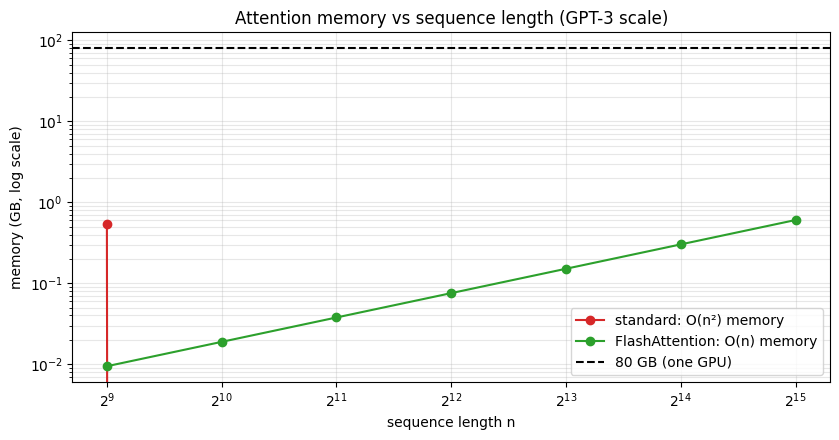

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
np.random.seed(0)

def attn_matrix_gb(n, n_heads, n_layers, batch=1, bytes_per=2):
    return n*n * n_heads * n_layers * batch * bytes_per / 1e9

seqs = np.array([1024, 4096, 16384, 65536])
print(f"{'seq len':>8s} {'attn matrix memory (GPT-3: 96 layers, 96 heads, bf16)':>50s}")
for n in seqs:
    print(f"{n:>8d} {attn_matrix_gb(n, 96, 96):>45.1f} GB")

fig, ax = plt.subplots(figsize=(8.5, 4.5))
ns = np.array([512, 1024, 2048, 4096, 8192, 16384, 32768])
ax.plot(ns, [attn_matrix_gb(n, 96, 96) for n in ns], "-o", color="tab:red", label="standard: O(n²) memory")
ax.plot(ns, [n*96*96*2/1e9 for n in ns], "-o", color="tab:green", label="FlashAttention: O(n) memory")
ax.axhline(80, ls="--", color="k", label="80 GB (one GPU)")
ax.set_xscale("log", base=2); ax.set_yscale("log")
ax.set_title("Attention memory vs sequence length (GPT-3 scale)")
ax.set_xlabel("sequence length n"); ax.set_ylabel("memory (GB, log scale)")
ax.legend(); ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()


**What to notice.** The standard $O(n^2)$ attention memory (red) explodes — at a 32k context it needs *thousands* of GB just for the score matrices, hopelessly beyond any GPU. FlashAttention's $O(n)$ memory (green) stays flat and tiny. This gap **is** the reason FlashAttention exists: without it, long context is impossible; with it, it's routine. Now let's build the algorithm that achieves the green line.


## 1. The key trick: online (streaming) softmax

Softmax needs the max and the sum over *all* elements — which seems to require having them all in memory at once. **Online softmax** computes it incrementally, one block at a time, maintaining a running max $m$ and running normalizer $\ell$, and *correcting* previous results when a new block reveals a larger max.

The math: suppose we've processed some elements and have running max $m_\text{old}$ and running sum $\ell_\text{old} = \sum \exp(x_i - m_\text{old})$. A new block arrives with its own max $m_\text{blk}$. Set $m_\text{new} = \max(m_\text{old}, m_\text{blk})$. Then rescale:
$$\ell_\text{new} = \underbrace{e^{m_\text{old} - m_\text{new}}}_{\text{correction}} \ell_\text{old} + \sum_{i \in \text{block}} e^{x_i - m_\text{new}}.$$
The correction factor $e^{m_\text{old}-m_\text{new}}$ retroactively "re-bases" the old sum to the new max — because if the new max is bigger, all the old exponentials were computed relative to too-small a max and must shrink. Let's verify this streaming computation equals the standard one.


In [2]:
def online_softmax_sum(x, block_size=8):
    """Compute sum(exp(x - max(x))) in a streaming fashion, one block at a time."""
    m = -np.inf     # running max
    l = 0.0         # running sum of exp(x - m)
    for start in range(0, len(x), block_size):
        blk = x[start:start+block_size]
        m_blk = blk.max()
        m_new = max(m, m_blk)
        l = np.exp(m - m_new) * l + np.exp(blk - m_new).sum()   # rescale old + add new
        m = m_new
    return l, m

x = np.random.randn(37) * 5      # arbitrary length, not a multiple of block size
l_online, m_online = online_softmax_sum(x, block_size=8)
# standard (needs all of x at once)
m_std = x.max(); l_std = np.exp(x - m_std).sum()
print(f"online : max={m_online:.6f}, sum={l_online:.6f}")
print(f"standard: max={m_std:.6f}, sum={l_std:.6f}")
print(f"max abs err: {abs(l_online - l_std):.2e}")
assert abs(l_online - l_std) < 1e-9
print("✅ online softmax equals standard softmax (computed without ever holding all elements)")


online : max=11.348773, sum=2.171086
standard: max=11.348773, sum=2.171086
max abs err: 8.88e-16
✅ online softmax equals standard softmax (computed without ever holding all elements)


**What to notice.** The streaming computation — which only ever holds *one block* plus two running scalars — gives the **exact** same softmax normalizer as the standard all-at-once version. That's the crux: softmax is "associative enough" to compute incrementally with a running max and a correction factor. FlashAttention applies this same trick to the whole attention operation, accumulating the output $O$ alongside $\ell$.


## 2. FlashAttention forward, from scratch

Now the full algorithm. We tile both queries and keys/values into blocks. For each **query block**, we stream over all **key/value blocks**, maintaining per-query running statistics $(m_i, \ell_i)$ and a running output accumulator $O_i$ — never forming the full score matrix. For each key block:
1. Compute the block's scores $S_{ij} = Q_i K_j^{\mathsf T}/\sqrt d$ (a small tile).
2. Update the running max $m_\text{new}$, compute $P_{ij} = \exp(S_{ij} - m_\text{new})$.
3. Rescale the running output and normalizer by the correction factor, then add this block's contribution $P_{ij} V_j$.
At the end, divide $O_i$ by $\ell_i$. The result is *exact* attention. Only $O(\text{block size})$ extra memory is ever live.


In [3]:
def flash_attention(Q, K, V, block=16):
    """Exact attention computed in tiles with online softmax. O(n) memory (no full n x n matrix)."""
    n, d = Q.shape
    O = np.zeros((n, d))
    for qs in range(0, n, block):
        Qi = Q[qs:qs+block]                          # query block
        m_i = np.full(Qi.shape[0], -np.inf)          # running max per query
        l_i = np.zeros(Qi.shape[0])                  # running normalizer per query
        Oi = np.zeros((Qi.shape[0], d))              # running output accumulator
        for ks in range(0, n, block):
            Kj, Vj = K[ks:ks+block], V[ks:ks+block]  # key/value block
            S = Qi @ Kj.T / np.sqrt(d)               # (block_q, block_k) small tile
            m_blk = S.max(axis=1)
            m_new = np.maximum(m_i, m_blk)
            P = np.exp(S - m_new[:, None])           # (block_q, block_k)
            corr = np.exp(m_i - m_new)               # correction for the running stats
            l_i = corr * l_i + P.sum(axis=1)
            Oi = corr[:, None] * Oi + P @ Vj         # rescale old output, add new block
            m_i = m_new
        O[qs:qs+block] = Oi / l_i[:, None]           # final normalization
    return O

def standard_attention(Q, K, V):
    d = Q.shape[1]
    S = Q @ K.T / np.sqrt(d)
    S = S - S.max(axis=1, keepdims=True)
    A = np.exp(S); A = A / A.sum(axis=1, keepdims=True)
    return A @ V

n, d = 64, 32
Q, K, V = np.random.randn(n, d), np.random.randn(n, d), np.random.randn(n, d)
O_flash = flash_attention(Q, K, V, block=16)
O_std   = standard_attention(Q, K, V)
print("FlashAttention vs standard attention, max abs err =", np.abs(O_flash - O_std).max())
assert np.abs(O_flash - O_std).max() < 1e-10
print("✅ FlashAttention produces EXACTLY the same output as standard attention")
print("   (but never materialized the 64x64 score matrix — only 16x16 tiles)")


FlashAttention vs standard attention, max abs err = 4.440892098500626e-16
✅ FlashAttention produces EXACTLY the same output as standard attention
   (but never materialized the 64x64 score matrix — only 16x16 tiles)


**What to notice.** FlashAttention gives the **exact same output** as standard attention (to machine precision) — it is *not* an approximation. Yet it never formed the full $n\times n$ score matrix; it only ever held a small $\text{block}\times\text{block}$ tile plus $O(n)$ running statistics. That's the whole magic: same math, radically less memory, by being clever about *the order of computation* (tiling + online softmax) rather than changing *what* is computed.

Let's confirm the peak memory difference by counting the largest intermediate each method holds.


In [4]:
def peak_intermediate_elems(n, d, block, method):
    if method == "standard":
        return n * n              # the full score matrix
    else:  # flash: largest live tile + running stats
        return block * block + block * d + n   # score tile + output tile + O(n) stats

ns = [128, 512, 2048, 8192]
print(f"{'n':>6s} {'standard (n²)':>16s} {'flash (tiled)':>16s} {'ratio':>10s}")
for n in ns:
    s = peak_intermediate_elems(n, 64, 32, "standard")
    f = peak_intermediate_elems(n, 64, 32, "flash")
    print(f"{n:>6d} {s:>16,d} {f:>16,d} {s/f:>9.0f}x")
print("\nFlash's peak intermediate grows ~linearly (dominated by the O(n) running stats),")
print("while standard's grows quadratically — the gap widens without bound.")


     n    standard (n²)    flash (tiled)      ratio
   128           16,384            3,200         5x
   512          262,144            3,584        73x
  2048        4,194,304            5,120       819x
  8192       67,108,864           11,264      5958x

Flash's peak intermediate grows ~linearly (dominated by the O(n) running stats),
while standard's grows quadratically — the gap widens without bound.


**What to notice.** The standard method's peak intermediate ($n^2$) dwarfs FlashAttention's (a fixed tile + $O(n)$ stats) by factors that grow with $n$ — thousands× at $n=8192$. That's the green-vs-red gap from §0, now from the algorithm's bookkeeping. (Real FlashAttention also gets a *speed* win — by keeping tiles in fast on-chip SRAM it does far fewer slow reads/writes to GPU main memory (HBM); attention is memory-bandwidth-bound, so fewer HBM trips ≈ 2–4× faster. That part needs a fused CUDA kernel, which is beyond NumPy, but the memory algorithm is exactly what we built.)

## 3. What you built / learned
- The **$O(n^2)$ memory wall** of standard attention and why it caps context length.
- **Online softmax**: compute softmax incrementally with a running max + correction factor; verified exact.
- **FlashAttention forward**: tile Q and K/V, stream with online softmax + output accumulation; verified to equal standard attention **exactly** with $O(n)$ memory.
- Why it also *speeds up* attention on GPUs (fewer HBM reads — it's memory-bandwidth-bound).

FlashAttention (and v2/v3) is one of the highest-impact systems papers in modern ML — it's in essentially every transformer trained today, and it's a perfect example of "same math, better memory access pattern" thinking.

## 4. Exercises
1. **Causal FlashAttention.** Add causal masking to the tiled algorithm (skip key blocks entirely in the future; mask within the diagonal block). Verify it matches masked standard attention.
2. **Block-size sweep.** Vary the block size; plot peak memory and (proxy) number of passes. What's the tradeoff?
3. **The backward pass.** FlashAttention recomputes the score tiles in the backward pass instead of storing them (trading compute for memory). Sketch why that's a good trade on a memory-bound op.
4. **Numerical stability.** Remove the running-max correction (use a fixed max of 0). Where does it break for large scores?
5. **Multi-query in tiles.** Combine with grouped-query attention (NB14): how does the tiling change when K/V heads are shared?
6. **Compare to `F.scaled_dot_product_attention`.** PyTorch's SDPA auto-selects a FlashAttention kernel on GPU — verify your NumPy output matches it, and read which backend it chose.

## 5. Interview / residency framing
- *"What problem does FlashAttention solve?"* → the $O(n^2)$ *memory* of the attention score matrix, which caps sequence length; also memory-bandwidth (speed).
- *"How, in one sentence?"* → tile Q/K/V and use online softmax to compute exact attention block-by-block, never materializing the full $n\times n$ matrix ⇒ $O(n)$ memory.
- *"What is online softmax?"* → streaming softmax with a running max and a correction factor $e^{m_\text{old}-m_\text{new}}$ that re-bases prior partial sums; exact, not approximate.
- *"Is it an approximation?"* → no — identical output to standard attention; it only changes the computation *order/memory pattern*.
- *"Why is it also faster?"* → attention is memory-bandwidth-bound; keeping tiles in on-chip SRAM slashes slow HBM reads/writes (needs a fused kernel).

---
**Next:** *Tier 3 · Notebook 17 — Parallelism*: data / tensor / pipeline / FSDP parallelism, the strategies for training a model too big for one GPU, each with a tiny runnable toy version.


## 📚 References & papers

This notebook reproduces / builds on:

- **FlashAttention: Fast and Memory-Efficient Exact Attention with IO-Awareness** — Dao et al. (2022), arXiv:2205.14135.
- **FlashAttention-2** — Dao (2023), arXiv:2307.08691.
- **Online normalizer calculation for softmax** — Milakov & Gimelshein (2018), arXiv:1805.02867.